# qiskit-stateviz — interactive Q-sphere & Bloch multivector demo

Interactive Plotly replacements for `qiskit.visualization.plot_state_qsphere` and `plot_bloch_multivector` — dark theme, free 360-degree rotation, a clear wireframe sphere, non-overlapping labels, and persistent numeric readouts, instead of a static matplotlib image.

This notebook is self-contained: it writes the package source directly into the Colab session and installs it locally, so it runs with no external dependency on a GitHub repo or PyPI release yet. Requires Qiskit SDK v2.0+ (matching the Qiskit Ecosystem compatibility requirement) — the install cell below just grabs the latest release.


## 1. Install dependencies

In [1]:
!pip install -q 'qiskit>=2.0' plotly pylatexenc


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00


## 2. Write the qiskit-stateviz package into this session

In [2]:
import os
os.makedirs('qiskit_stateviz', exist_ok=True)


In [3]:
%%writefile qiskit_stateviz/__init__.py
"""qiskit-stateviz: interactive Plotly-based statevector visualizations for Qiskit.

Native replacements for the static matplotlib views in
``qiskit.visualization`` (``plot_state_qsphere``, ``plot_bloch_multivector``),
built directly against current Qiskit ``Statevector`` / ``DensityMatrix``
objects and Qiskit SDK v2.x — no dependency on deprecated packages like
``qiskit-terra`` or ``qiskit-ibmq-provider``.
"""

from .bloch import plot_bloch_multivector_interactive
from .qsphere import plot_qsphere_interactive
from .utils import StateVizError

__version__ = "0.1.0"

__all__ = [
    "plot_qsphere_interactive",
    "plot_bloch_multivector_interactive",
    "StateVizError",
]


Writing qiskit_stateviz/__init__.py


In [4]:
%%writefile qiskit_stateviz/utils.py
"""Shared helpers for coercing Qiskit state objects into plain numpy arrays."""

from __future__ import annotations

import numpy as np


class StateVizError(Exception):
    """Raised for invalid or unsupported input states."""


def _is_power_of_two(n: int) -> bool:
    return n > 0 and (n & (n - 1)) == 0


def to_statevector_array(state) -> np.ndarray:
    """Coerce a Qiskit ``Statevector``, list, or ndarray into a 1D complex ndarray.

    Accepts:
      * ``qiskit.quantum_info.Statevector``
      * any object exposing a ``.data`` attribute that is array-like
      * a plain list / tuple / numpy array of amplitudes

    Raises:
        StateVizError: if the input is not a valid pure-state vector of
            dimension 2**n for some integer n, or is not normalized.
    """
    data = state.data if hasattr(state, "data") else state
    arr = np.asarray(data, dtype=complex).flatten()

    if not _is_power_of_two(arr.shape[0]):
        raise StateVizError(
            f"Statevector length {arr.shape[0]} is not a power of 2 "
            "(qiskit-stateviz only supports qubit systems)."
        )

    norm = np.linalg.norm(arr)
    if not np.isclose(norm, 1.0, atol=1e-6):
        raise StateVizError(
            f"Input state is not normalized (||psi|| = {norm:.6f}). "
            "Pass a valid Statevector or normalized amplitude array."
        )

    return arr


def to_density_matrix_array(state) -> np.ndarray:
    """Coerce a Qiskit ``DensityMatrix``, ``Statevector``, or ndarray into a
    2D density matrix ndarray.

    If given a pure statevector-like input, promotes it to |psi><psi|.
    """
    data = state.data if hasattr(state, "data") else state
    arr = np.asarray(data, dtype=complex)

    if arr.ndim == 1:
        sv = to_statevector_array(arr)
        return np.outer(sv, sv.conj())

    if arr.ndim != 2 or arr.shape[0] != arr.shape[1]:
        raise StateVizError(
            f"Expected a square density matrix, got shape {arr.shape}."
        )

    if not _is_power_of_two(arr.shape[0]):
        raise StateVizError(
            f"Density matrix dimension {arr.shape[0]} is not a power of 2 "
            "(qiskit-stateviz only supports qubit systems)."
        )

    return arr


def num_qubits_from_dim(dim: int) -> int:
    return int(np.log2(dim))


def partial_trace_to_single_qubit(rho: np.ndarray, qubit: int, n: int) -> np.ndarray:
    """Partial trace of an n-qubit density matrix down to a single qubit's 2x2 rho.

    Uses Qiskit's little-endian qubit ordering convention (qubit 0 is the
    least-significant / rightmost bit in the computational basis label).

    Implemented via ``np.einsum`` with explicit index letters: this is O(1)
    to get right for arbitrary n, unlike manual axis-bookkeeping with
    repeated ``np.trace`` calls (which is easy to get subtly wrong).
    """
    import string

    rho_t = rho.reshape([2] * n + [2] * n)

    # Axis i (0..n-1) is the bra index for qubit (n-1-i); axis n+i is the
    # matching ket index for the same qubit. This is standard row-major
    # reshape order combined with Qiskit's little-endian labeling.
    #
    # The kept qubit needs *distinct* bra/ket letters (it's not traced);
    # every traced qubit shares one letter between its bra and ket axis.
    kept_bra, kept_ket = "y", "z"
    bra_letters = []
    ket_letters = []
    pool = [c for c in string.ascii_lowercase if c not in (kept_bra, kept_ket)]
    if n - 1 > len(pool):
        raise StateVizError(f"Too many qubits ({n}) for einsum-based partial trace.")
    trace_letter_iter = iter(pool)
    for i in range(n):
        this_qubit = n - 1 - i
        if this_qubit == qubit:
            bra_letters.append(kept_bra)
            ket_letters.append(kept_ket)
        else:
            L = next(trace_letter_iter)
            bra_letters.append(L)
            ket_letters.append(L)

    subscript = "".join(bra_letters) + "".join(ket_letters) + f"->{kept_bra}{kept_ket}"
    return np.einsum(subscript, rho_t)


PAULI_X = np.array([[0, 1], [1, 0]], dtype=complex)
PAULI_Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
PAULI_Z = np.array([[1, 0], [0, -1]], dtype=complex)


def bloch_vector_from_rho1(rho1: np.ndarray) -> tuple[float, float, float]:
    """Compute the (x, y, z) Bloch vector components of a single-qubit density matrix."""
    x = np.real(np.trace(rho1 @ PAULI_X))
    y = np.real(np.trace(rho1 @ PAULI_Y))
    z = np.real(np.trace(rho1 @ PAULI_Z))
    return float(x), float(y), float(z)


Writing qiskit_stateviz/utils.py


In [5]:
%%writefile qiskit_stateviz/qsphere.py
"""Interactive Q-sphere visualization for n-qubit pure statevectors."""

from __future__ import annotations

import numpy as np
import plotly.graph_objects as go

from .utils import num_qubits_from_dim, to_statevector_array

# Dark theme palette, shared across all traces in this module.
_BG = "#111318"
_GRID_BOLD = "#9aa0aa"
_GRID_LIGHT = "#3a3f4a"
_TEXT = "#e8e8ea"
_GHOST_MARKER = "#5a5f6a"
_GHOST_TEXT = "#7d828c"
_STEM = "#7a8090"


def _hamming_weight(i: int) -> int:
    return bin(i).count("1")


def _ring_positions(indices: list[int], weight: int, n: int) -> list[tuple[float, float, float]]:
    """Place basis states of a given Hamming weight evenly around a latitude ring.

    weight=0 -> north pole, weight=n -> south pole, matching Qiskit's own
    plot_state_qsphere convention.
    """
    theta = np.pi * weight / n if n > 0 else 0.0
    z = np.cos(theta)
    r_xy = np.sin(theta)

    count = len(indices)
    positions = []
    for k in range(count):
        # Poles (weight 0 or n) have a single point; avoid divide-by-zero.
        phi = 2 * np.pi * k / count if count > 0 else 0.0
        x = r_xy * np.cos(phi)
        y = r_xy * np.sin(phi)
        positions.append((x, y, z))
    return positions


def _sphere_wireframe_traces(n: int):
    """A wireframe sphere: a latitude ring at each Hamming-weight level
    (the same rings basis states are placed on) plus several meridians,
    so the shape reads clearly as a sphere and the rings carry meaning
    (each one is exactly where a given weight's basis states sit).
    """
    traces = []
    t = np.linspace(0, 2 * np.pi, 60)

    def circle(x, y, z, color, width):
        return go.Scatter3d(
            x=x, y=y, z=z,
            mode="lines", line=dict(color=color, width=width),
            hoverinfo="skip", showlegend=False,
        )

    bold, light = _GRID_BOLD, _GRID_LIGHT

    for w in range(n + 1):
        theta = np.pi * w / n if n > 0 else 0.0
        z = np.cos(theta)
        r = np.sin(theta)
        if r < 1e-9:
            continue
        color = bold if w in (0, n) or w == n / 2 else light
        traces.append(circle(r * np.cos(t), r * np.sin(t), np.full_like(t, z), color, 2))

    for phi in (0, np.pi / 2, np.pi / 4, 3 * np.pi / 4):
        color = bold if phi in (0, np.pi / 2) else light
        traces.append(circle(np.cos(t) * np.cos(phi), np.cos(t) * np.sin(phi), np.sin(t), color, 2))

    return traces


def plot_qsphere_interactive(
    state,
    *,
    prob_tol: float = 1e-10,
    show_labels: bool = True,
    colorscale: str = "hsv",
    marker_scale: float = 40.0,
    title: str = "Q-sphere",
    height: int = 650,
) -> go.Figure:
    """Render an interactive Plotly Q-sphere for an n-qubit pure state.

    Args:
        state: a ``qiskit.quantum_info.Statevector``, or any array-like of
            length 2**n giving the complex amplitudes.
        prob_tol: basis states with probability below this threshold are
            omitted from the plot.
        show_labels: whether to label each basis state with its ket
            notation. Every basis state is labeled, not just populated
            ones — unpopulated states are shown as small faint "ghost"
            points so the full 2**n structure of the sphere stays visible.
        colorscale: a Plotly colorscale name used to map relative phase to
            color (default ``"hsv"``, appropriate for a cyclic quantity).
        marker_scale: scales marker size, which is proportional to
            probability.
        title: plot title.
        height: figure height in pixels.

    Returns:
        A ``plotly.graph_objects.Figure``. Call ``.show()`` to display it,
        or return it directly from a Jupyter cell. Drag freely (360-degree
        orbit) to rotate, scroll/pinch to zoom. Rendered on a dark
        background.
    """
    amplitudes = to_statevector_array(state)
    dim = amplitudes.shape[0]
    n = num_qubits_from_dim(dim)

    probs = np.abs(amplitudes) ** 2
    keep = np.where(probs > prob_tol)[0]
    if keep.size == 0:
        raise ValueError("All basis state probabilities are below prob_tol.")

    # Recenter phase relative to the first surviving amplitude, matching
    # Qiskit's convention of removing an unobservable global phase.
    ref_phase = np.angle(amplitudes[keep[0]])

    # Every possible basis state gets a ring position and a label — not
    # just the populated ones — so the full structure of the sphere is
    # visible. This also removes the earlier double-labeling bug, where
    # a separate "pole label" trace and the per-point label trace both
    # drew text at the |00...0> / |11...1> poles whenever those states
    # happened to be populated.
    all_indices = np.arange(dim)
    all_weights = np.array([_hamming_weight(int(i)) for i in all_indices])

    all_xs, all_ys, all_zs, all_idx_ordered = [], [], [], []
    for w in range(n + 1):
        idx_at_weight = all_indices[all_weights == w]
        positions = _ring_positions(list(idx_at_weight), w, n)
        for idx, (x, y, z) in zip(idx_at_weight, positions):
            all_xs.append(x)
            all_ys.append(y)
            all_zs.append(z)
            all_idx_ordered.append(int(idx))

    all_xs = np.array(all_xs)
    all_ys = np.array(all_ys)
    all_zs = np.array(all_zs)
    all_idx_ordered = np.array(all_idx_ordered)
    is_populated = np.isin(all_idx_ordered, keep)

    # textposition per point, chosen by hemisphere so labels are pushed
    # away from the sphere's center in projection rather than centered
    # exactly on the marker (which is what caused labels to visually
    # collide with the wireframe/other labels at small sizes).
    textpositions = np.where(all_zs >= 0, "top center", "bottom center")

    fig = go.Figure()

    for trace in _sphere_wireframe_traces(n):
        fig.add_trace(trace)

    # Stems from center to each *populated* amplitude only — stems for
    # unpopulated ghost points would just add clutter with no information.
    for i, x, y, z in zip(all_idx_ordered, all_xs, all_ys, all_zs):
        if i not in keep:
            continue
        fig.add_trace(
            go.Scatter3d(
                x=[0, x], y=[0, y], z=[0, z],
                mode="lines",
                line=dict(color=_STEM, width=2),
                hoverinfo="skip",
                showlegend=False,
            )
        )

    # Ghost markers: every basis state that currently has ~zero amplitude,
    # shown faint with a label, so the full basis is always visible.
    ghost_mask = ~is_populated
    if show_labels and ghost_mask.any():
        ghost_labels = [
            f"|{format(int(i), f'0{n}b')}⟩" for i in all_idx_ordered[ghost_mask]
        ]
        fig.add_trace(
            go.Scatter3d(
                x=all_xs[ghost_mask], y=all_ys[ghost_mask], z=all_zs[ghost_mask],
                mode="markers+text",
                marker=dict(size=4, color=_GHOST_MARKER),
                text=ghost_labels,
                textfont=dict(size=11, color=_GHOST_TEXT),
                textposition=list(textpositions[ghost_mask]),
                hoverinfo="skip",
                showlegend=False,
            )
        )
    elif ghost_mask.any():
        fig.add_trace(
            go.Scatter3d(
                x=all_xs[ghost_mask], y=all_ys[ghost_mask], z=all_zs[ghost_mask],
                mode="markers",
                marker=dict(size=4, color=_GHOST_MARKER),
                hoverinfo="skip",
                showlegend=False,
            )
        )

    pop_idx = all_idx_ordered[is_populated]
    pop_xs, pop_ys, pop_zs = all_xs[is_populated], all_ys[is_populated], all_zs[is_populated]
    pop_probs = probs[pop_idx]
    pop_phases = (np.angle(amplitudes[pop_idx]) - ref_phase + np.pi) % (2 * np.pi) - np.pi
    pop_sizes = marker_scale * np.sqrt(pop_probs / pop_probs.max())
    pop_labels = [f"|{format(int(i), f'0{n}b')}⟩" for i in pop_idx]

    hover_text = [
        f"{lbl}<br>amplitude: {amplitudes[i]:.4f}<br>"
        f"probability: {p:.4f}<br>phase: {ph:.4f} rad"
        for lbl, i, p, ph in zip(pop_labels, pop_idx, pop_probs, pop_phases)
    ]

    fig.add_trace(
        go.Scatter3d(
            x=pop_xs, y=pop_ys, z=pop_zs,
            mode="markers+text" if show_labels else "markers",
            marker=dict(
                size=pop_sizes,
                color=pop_phases,
                colorscale=colorscale,
                cmin=-np.pi,
                cmax=np.pi,
                colorbar=dict(title="phase (rad)", tickfont=dict(color=_TEXT), title_font=dict(color=_TEXT)),
                line=dict(color=_BG, width=0.5),
            ),
            text=pop_labels if show_labels else None,
            textfont=dict(size=13, color=_TEXT),
            textposition=list(textpositions[is_populated]) if show_labels else None,
            hovertext=hover_text,
            hoverinfo="text",
            showlegend=False,
        )
    )

    fig.update_layout(
        title=title,
        height=height,
        template="plotly_dark",
        paper_bgcolor=_BG,
        font=dict(color=_TEXT),
        scene=dict(
            xaxis=dict(visible=False, range=[-1.3, 1.3]),
            yaxis=dict(visible=False, range=[-1.3, 1.3]),
            zaxis=dict(visible=False, range=[-1.3, 1.3]),
            aspectmode="cube",
            dragmode="orbit",
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.1)),
            bgcolor=_BG,
        ),
        margin=dict(l=0, r=0, t=40, b=0),
    )
    return fig


Writing qiskit_stateviz/qsphere.py


In [6]:
%%writefile qiskit_stateviz/bloch.py
"""Interactive Bloch-multivector visualization for n-qubit states."""

from __future__ import annotations

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from .utils import (
    bloch_vector_from_rho1,
    num_qubits_from_dim,
    partial_trace_to_single_qubit,
    to_density_matrix_array,
)

# Dark theme palette, shared across all traces in this module.
_BG = "#111318"
_GRID_BOLD = "#9aa0aa"
_GRID_LIGHT = "#3a3f4a"
_TEXT = "#e8e8ea"
_AXIS_LINE = "#555c68"
_ORIGIN = "#8a8f99"

# Standard Bloch-sphere basis labels are attached to their poles directly
# inside _pole_label_trace(), where each also gets a distinct textposition.


def _sphere_wireframe_traces():
    """A wireframe sphere: equator, two primary meridians (bold), two
    secondary meridians and two latitude circles (light), for a shape
    that reads clearly as a sphere without turning into a tangled glob
    of overlapping circles.
    """
    traces = []
    t = np.linspace(0, 2 * np.pi, 60)

    def circle(x, y, z, color, width):
        return go.Scatter3d(
            x=x, y=y, z=z,
            mode="lines", line=dict(color=color, width=width),
            hoverinfo="skip", showlegend=False,
        )

    # Primary great circles: equator + the two meridians aligned with the
    # x and y axes. These three alone define the sphere's silhouette from
    # any angle.
    traces.append(circle(np.cos(t), np.sin(t), np.zeros_like(t), _GRID_BOLD, 3))
    traces.append(circle(np.cos(t), np.zeros_like(t), np.sin(t), _GRID_BOLD, 3))
    traces.append(circle(np.zeros_like(t), np.cos(t), np.sin(t), _GRID_BOLD, 3))

    # Secondary meridians at 45/135 degrees, for extra 3D shape cues.
    for phi in (np.pi / 4, 3 * np.pi / 4):
        traces.append(
            circle(np.cos(t) * np.cos(phi), np.cos(t) * np.sin(phi), np.sin(t), _GRID_LIGHT, 1.5)
        )

    # Two latitude circles above/below the equator.
    for z in (0.5, -0.5):
        r = np.sqrt(1 - z ** 2)
        traces.append(circle(r * np.cos(t), r * np.sin(t), np.full_like(t, z), _GRID_LIGHT, 1.5))

    return traces


def _axis_lines():
    lines = []
    for coords in (
        {"x": [-1, 1], "y": [0, 0], "z": [0, 0]},
        {"x": [0, 0], "y": [-1, 1], "z": [0, 0]},
        {"x": [0, 0], "y": [0, 0], "z": [-1, 1]},
    ):
        lines.append(
            go.Scatter3d(
                x=coords["x"], y=coords["y"], z=coords["z"],
                mode="lines",
                line=dict(color=_AXIS_LINE, width=1),
                hoverinfo="skip",
                showlegend=False,
            )
        )
    return lines


def _pole_label_trace():
    # Distinct textposition per pole so labels spread outward in different
    # projected directions rather than all being centered exactly on their
    # 3D point (which is what caused labels to crowd/overlap each other
    # and the vector at small subplot sizes).
    entries = [
        ((0, 0, 1), "|0⟩", "top center"),
        ((0, 0, -1), "|1⟩", "bottom center"),
        ((1, 0, 0), "|+⟩", "middle right"),
        ((-1, 0, 0), "|−⟩", "middle left"),
        ((0, 1, 0), "|+i⟩", "top right"),
        ((0, -1, 0), "|−i⟩", "bottom left"),
    ]
    xs = [x * 1.55 for (x, y, z), _, _ in entries]
    ys = [y * 1.55 for (x, y, z), _, _ in entries]
    zs = [z * 1.55 for (x, y, z), _, _ in entries]
    labels = [lbl for _, lbl, _ in entries]
    positions = [pos for _, _, pos in entries]
    return go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode="text",
        text=labels,
        textfont=dict(size=13, color=_TEXT),
        textposition=positions,
        hoverinfo="skip",
        showlegend=False,
    )


def _vector_traces(bx: float, by: float, bz: float, q: int, color: str):
    """Render the Bloch vector as a chain of markers plus a tip marker.

    Plotly's WebGL 3D line width is unreliable across browsers/GPUs — a
    ``width=8`` line can silently render as a 1px hairline that gets lost
    against wireframe/axis clutter. A short trail of solid markers along
    the vector, plus a larger marker at the tip, is visible everywhere
    regardless of that limitation.
    """
    r = np.sqrt(bx ** 2 + by ** 2 + bz ** 2)
    n_dots = max(2, int(np.ceil(r * 18)))
    ts = np.linspace(0, 1, n_dots)
    xs, ys, zs = bx * ts, by * ts, bz * ts

    trail = go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode="markers",
        marker=dict(size=5, color=color, opacity=0.9),
        hoverinfo="skip",
        showlegend=False,
    )

    tip_hover = (
        f"qubit {q}<br>x={bx:.4f}<br>y={by:.4f}<br>z={bz:.4f}<br>"
        f"|r|={r:.4f}"
    )
    tip = go.Scatter3d(
        x=[bx], y=[by], z=[bz],
        mode="markers",
        marker=dict(size=10, color=color, symbol="diamond",
                    line=dict(color="#00272b", width=1)),
        hovertext=[tip_hover],
        hoverinfo="text",
        showlegend=False,
    )

    origin = go.Scatter3d(
        x=[0], y=[0], z=[0],
        mode="markers",
        marker=dict(size=4, color=_ORIGIN),
        hovertext=[f"qubit {q} (origin)"],
        hoverinfo="text",
        showlegend=False,
    )

    return [origin, trail, tip]


def plot_bloch_multivector_interactive(
    state,
    *,
    vector_color: str = "#00B4D8",
    title: str = "Bloch multivector",
    height: int = 460,
) -> go.Figure:
    """Render one interactive Bloch sphere per qubit, side by side.

    Each sphere shows the reduced single-qubit Bloch vector, i.e. the
    expectation values of X, Y, Z on that qubit after tracing out all
    others. This matches ``qiskit.visualization.plot_bloch_multivector``
    semantically, but is fully interactive rather than a static
    matplotlib image: drag to freely orbit each sphere in any direction,
    scroll/pinch to zoom, and hover the vector tip for exact values. Each
    sphere is labeled at its six basis poles (|0⟩, |1⟩, |+⟩, |−⟩, |+i⟩,
    |−i⟩), each pushed outward with its own text anchor so the six labels
    don't crowd each other or the vector, and its numeric Bloch-vector
    coordinates are shown directly under the subplot title, so the values
    are visible without hovering. Rendered on a dark background.

    Note: as with Qiskit's own ``plot_bloch_multivector``, this view shows
    only single-qubit marginals. It cannot represent entanglement between
    qubits — a maximally entangled qubit's Bloch vector has zero length,
    even though the full joint state is far from mixed. Use
    :func:`qiskit_stateviz.qsphere.plot_qsphere_interactive` (pure states)
    to see multi-qubit structure directly.

    Args:
        state: a ``qiskit.quantum_info.Statevector`` or ``DensityMatrix``,
            or an equivalent array-like.
        vector_color: color of the Bloch vector trail/tip on each sphere.
            Defaults to an aqua blue (``#00B4D8``).
        title: overall figure title.
        height: figure height in pixels.

    Returns:
        A ``plotly.graph_objects.Figure`` with one freely-rotatable 3D
        subplot per qubit.
    """
    rho = to_density_matrix_array(state)
    n = num_qubits_from_dim(rho.shape[0])

    bloch_vectors = []
    for q in range(n):
        rho1 = partial_trace_to_single_qubit(rho, q, n)
        bloch_vectors.append(bloch_vector_from_rho1(rho1))

    specs = [[{"type": "scene"} for _ in range(n)]]
    subplot_titles = [
        f"qubit {q}<br>(x={bx:.3f}, y={by:.3f}, z={bz:.3f})"
        for q, (bx, by, bz) in enumerate(bloch_vectors)
    ]
    fig = make_subplots(
        rows=1, cols=n, specs=specs, subplot_titles=subplot_titles,
        horizontal_spacing=min(0.15, 0.6 / max(n, 1)),
    )

    for q, (bx, by, bz) in enumerate(bloch_vectors):
        for trace in _sphere_wireframe_traces():
            fig.add_trace(trace, row=1, col=q + 1)
        for line in _axis_lines():
            fig.add_trace(line, row=1, col=q + 1)
        fig.add_trace(_pole_label_trace(), row=1, col=q + 1)
        for trace in _vector_traces(bx, by, bz, q, vector_color):
            fig.add_trace(trace, row=1, col=q + 1)

    scene_updates = {}
    for q in range(n):
        key = "scene" if q == 0 else f"scene{q + 1}"
        scene_updates[key] = dict(
            xaxis=dict(visible=False, range=[-1.75, 1.75]),
            yaxis=dict(visible=False, range=[-1.75, 1.75]),
            zaxis=dict(visible=False, range=[-1.75, 1.75]),
            aspectmode="cube",
            dragmode="orbit",
            # Pulled back slightly (was 1.4) so poles/labels near the
            # edge of the sphere have breathing room instead of nearly
            # touching the subplot title above them.
            camera=dict(eye=dict(x=1.7, y=1.7, z=1.3)),
            bgcolor=_BG,
        )

    fig.update_layout(
        title=title,
        height=height,
        margin=dict(l=0, r=0, t=90, b=0),
        template="plotly_dark",
        paper_bgcolor=_BG,
        font=dict(color=_TEXT),
        **scene_updates,
    )
    fig.update_annotations(font=dict(color=_TEXT))
    return fig


Writing qiskit_stateviz/bloch.py


## 3. Import and build a GHZ state

Qiskit version: 2.5.1


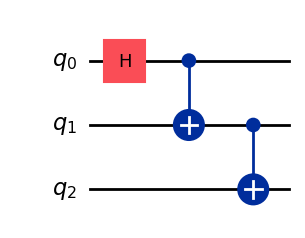

In [7]:
import sys
sys.path.insert(0, '.')

import qiskit
print('Qiskit version:', qiskit.__version__)

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_stateviz import plot_qsphere_interactive, plot_bloch_multivector_interactive

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)  # 3-qubit GHZ state: (|000> + |111>) / sqrt(2)

sv = Statevector(qc)
qc.draw('mpl')


## 4. Interactive Q-sphere
Drag to freely orbit in any direction (full 360°), scroll/pinch to zoom. Every computational basis state is labeled — populated states (here |000⟩ and |111⟩) are colored by phase and sized by probability; every other basis state still shows as a small labeled 'ghost' point so the full structure of the sphere is always visible. Hover a populated point for exact amplitude, probability, and phase.

Note: GHZ only populates the two poles, so rotating around the vertical axis alone won't show anything new here — tilt the view instead. Section 6 below has a state designed specifically to need full rotation.

In [8]:
fig_qsphere = plot_qsphere_interactive(sv, title='GHZ state — Q-sphere')
fig_qsphere.show()


## 5. Interactive Bloch multivector
One freely-rotatable (drag = full 360° orbit, no fixed axis) Bloch sphere per qubit. All six basis poles are labeled (|0⟩, |1⟩, |+⟩, |−⟩, |+i⟩, |−i⟩), each pushed outward in its own direction so the labels spread apart instead of overlapping each other or the vector. The numeric (x, y, z) Bloch vector is shown right under each subplot title — no hovering required to read the values.

Each qubit's vector is drawn as an aqua-blue trail of dots from the origin to a diamond tip, rather than a thin 3D line — Plotly's WebGL line width is unreliable across browsers/GPUs, so a plain line can silently render as an invisible hairline. The dot trail is visible everywhere.

Notice each qubit's Bloch vector is (near) zero-length here — a maximally entangled qubit's single-qubit marginal is maximally mixed, even though the full 3-qubit state is pure. The Q-sphere above shows the entanglement structure that this view cannot.

In [9]:
fig_bloch = plot_bloch_multivector_interactive(sv, title='GHZ state — Bloch multivector')
fig_bloch.show()


## 6. States built to actually need rotation
GHZ is a clean *concept* demo, but a weak *rotation* demo — its Q-sphere only populates the two poles, so spinning around the vertical axis shows nothing new. These two states are chosen specifically to require dragging around to see everything.

### Q-sphere: all 8 basis states populated, across every ring
This state populates every one of the 8 basis states for 3 qubits, spread across all 4 Hamming-weight rings (poles + two 3-point rings), each with a different phase (so different colors). The two 3-point rings are the key part: from any single fixed camera angle you can only see 1–2 of the 3 points on each ring — **drag to orbit around the vertical axis** and watch the hidden points on the far side come into view.

In [10]:
qc_rot = QuantumCircuit(3)
qc_rot.h(0)
qc_rot.h(1)
qc_rot.h(2)
qc_rot.t(0)
qc_rot.s(1)
qc_rot.cz(1, 2)
sv_rot = Statevector(qc_rot)

plot_qsphere_interactive(
    sv_rot, title='All 8 basis states, all 4 rings — try rotating around the vertical axis'
).show()


### Bloch multivector: three independent, off-axis vectors
Three unentangled qubits, each given a different single-qubit rotation landing at a genuinely 3D point — none of the three vectors sit on an axis, and none of them are coplanar with each other. A single camera angle makes at least one of them look foreshortened or ambiguous — **drag each sphere** to confirm the true direction.

In [11]:
qc_rot2 = QuantumCircuit(3)
qc_rot2.u(1.0, 0.3, 0.7, 0)
qc_rot2.u(2.0, 1.1, 0.2, 1)
qc_rot2.u(0.5, 2.4, 1.8, 2)
sv_rot2 = Statevector(qc_rot2)

plot_bloch_multivector_interactive(
    sv_rot2, title='Three independent, off-axis Bloch vectors — rotate each sphere'
).show()


## 7. Try your own circuit
The functions accept a `Statevector`, a `DensityMatrix` (for the Bloch view), or a plain `numpy` amplitude array — swap in anything here.

In [12]:
# Your circuit here
qc3 = QuantumCircuit(2)
qc3.h(0)
qc3.cx(0, 1)
sv3 = Statevector(qc3)

plot_qsphere_interactive(sv3, title='Your state — Q-sphere').show()
plot_bloch_multivector_interactive(sv3, title='Your state — Bloch view').show()
